# 075. Poetry text generation - seq2seq Transfer Learning

## Korean word2vec 을 embedding layer 의 초기 weight 로 전이학습


- 두개의 model 로 구성  
    - model1 : many-to-many RNN model for fine tuning
    - model2 : many-to-many RNN model for sequence-to-sequence prediction
    

- Model 1 에서 Embedding Layer 를 훈련 시키고, 훈련시킨 Embedding 을 Model 2 에서 Text Generation 에 사용  


- Model 1 은 word2vec pre-trained weight 를 초기값으로 사용하고, single LSTM 으로 fine tuning  


- Model 2 는 Model 1 에서 train 된 Embedding + LSTM 의 이전 timestep prediction 의 hidden state 와 cell state 를 초기값으로 사용


- Model 2 에서는 idx = np.random.choice(len(probs), p=probs) $\rightarrow$ 사후 확률분포 (posterios probability distribution) 에 의해 next word sampling

<img src="seq2seq.png" width="600"/>

In [1]:
# !pip install -U gensim==3.6.0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models.word2vec import Word2Vec
import gensim

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

In [5]:
# some configuration
MAX_VOCAB_SIZE = 3000
EMBEDDING_DIM = 200
BATCH_SIZE = 128
LATENT_DIM = 64

### Teacher Forcing 을 위한 input, target data 작성
- input data 와 target data 는 1 timestep offset 차이로 동일  
- input 은 start token 으로 시작  
- output 은 end token 으로 종료  


input data : `<sos> 앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.`  
target data : `앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요. <eos>`

In [6]:
file_path = tf.keras.utils.get_file("Alice_wonderland_Korean.txt", 
              "https://github.com/ironmanciti/NLP_Lecture/raw/master/data/Alice_wonderland_Korean.txt")

In [7]:
# load in the data
input_texts = []
target_texts = []

f = open(file_path,"r", encoding='cp949')

for line in f:
    line = line.rstrip()
    if not line:
        continue

    input_line = '<sos> ' + line 
    target_line = line + ' <eos>'

    input_texts.append(input_line)
    target_texts.append(target_line)

print(input_texts[:5])
print()
print(target_texts[:5])

['<sos> 앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.', '<sos> 그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요.', '<sos> ‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’', '<sos> 그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요.', '<sos> ‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’']

['앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요. <eos>', '그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요. <eos>', '‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’ <eos>', '그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요. <eos>', '‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’ <eos>']


### sentences (string) 을 integer 로 변환 
- Tokenizer 의 두가지 기능
    - text 내의 word 들을 split 하여 index 부여 (Tokenizer.fit_on_texts)  
    - text 를 word 의 index 로 sequence 변환 (Tokenizer.texts_to_sequences)
    
    
- Tokenizer 의 filters='' 를 해주지 않으면 모든 special character 를 filtering 하므로 `<sos>, <eos>` 의 <, > 가 제거됨  
    - 구둣점들을 filtering 해주지 않아도 최종 performance 에 큰 문제 없음

In [8]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(input_texts + target_texts)

# word index 길이 
print('Found %s unique tokens.' % len(tokenizer.word_index))

# string -> sequence 변환
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print(len(input_sequences), len(target_sequences))
print(input_sequences[:3])
print(target_sequences[:3])
print(tokenizer.word_index.get('<sos>'))
print(tokenizer.word_index.get('<eos>'))

Found 9021 unique tokens.
1422 1422
[[1, 6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67], [1, 125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45], [1, 2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261]]
[[6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67, 2], [125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45, 2], [2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261, 2]]
1
2


### padding
- 모든 input 을 동일한 length 로 padding 하기 위해 max sequence length 구함
- 모든 input 과 target 을 동일 length 로 padding  

- N x T matrix 생성 (N: sentence 갯수, T: max sequence length) 

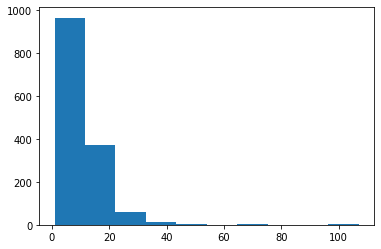

In [9]:
plt.hist([len(s) for s in input_sequences]);

In [10]:
MAX_SEQ_LEN = 20

In [11]:
# pad sequences so that we get a N x T matrix
input_padded = pad_sequences(input_sequences, maxlen=MAX_SEQ_LEN, padding='post')
target_padded = pad_sequences(target_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(input_padded.shape)
print(target_padded.shape)
print(input_padded[0])
print(target_padded[0])

(1422, 20)
(1422, 20)
[   1    6 1209  457   94 2248  377 1210 2249   10 2250   67    0    0
    0    0    0    0    0    0]
[   6 1209  457   94 2248  377 1210 2249   10 2250   67    2    0    0
    0    0    0    0    0    0]


### embeding layer 의 num_words

In [12]:
num_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

### pretrained word embedding 값을 transfer learning

- Embedding layer 의 weight 를 pre-trained model 로 초기화  


- 한글 word2vec 의 EMBEDDING_DIM 사용  


- word index 가 1 부터 시작하므로 0 padding 감안하여 num_words 는 len(word2idx)+1, 혹은 MAX_VOCAB_SIZE 중 작은 것 선택  

In [13]:
kovec = Word2Vec.load('https://github.com/ironmanciti/NLP_Lecture/raw/master/data/ko.bin')

In [14]:
words = list(kovec.wv.vocab.keys())
print(len(words))
print(words[:30])

30185
['관위', '정어리', '유식론', '장로회', '춘추관', '도입부', '민병', '어렵', '매니저', '청담', '광주시', '고민', '어로', '어록', '폴라리스', '십만', '관음', '효과적', '관의', '당뇨병', '영중추', '듣', '민법', '마두라', '중국계', '여덟째', 'ㄴ단', 'ㄴ다', '테스트', '어찌하']


In [15]:
embeddings_dict = {}

for word in words:                                     
    embeddings_dict[word] = kovec.wv[word]
    
len(embeddings_dict)

30185

In [16]:
embedding_matrix = np.zeros((num_words, 200))    # zero 로 초기화   
    
for word, i in tokenizer.word_index.items():
    if i < num_words :
        embedding_vector = embeddings_dict.get(word)
        if embedding_vector is not None:      # 해당 word 가 없으면 all zero 로 남겨둠
            embedding_matrix[i] = embedding_vector

### Embedding layer 작성
- load pre-trained word embeddings into an Embedding layer

In [17]:
embedding_layer = Embedding(num_words, EMBEDDING_DIM, weights=[embedding_matrix])

## 전이학습 및 fine-tuning 을 위한 embedding +  single LSTM model 생성

- return_sequence = True 일 경우 lstm 의 output 은 x, h, c 
- model 은 [input_, initial_h, initial_c] 의 3 개의 input 과, 하나의 output 을 가진다. initial_state 를 keras default 를 사용하지 않고 직접 control 하기 위해 initial_h 와 initial_c 를 추가  

In [18]:
input1 = Input(shape=(MAX_SEQ_LEN,))
x = embedding_layer(input1)
lstm = LSTM(LATENT_DIM, return_sequences=True)
x = lstm(x)

output1 = Dense(num_words, activation='softmax')(x)
model_1 = Model(input1, output1)

model_1.compile(loss='sparse_categorical_crossentropy', 
                optimizer=Adam(learning_rate=0.01),
                metrics=['accuracy'])   # poet 생성에서는 accuracy 큰 의미 없음
model_1.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 20)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 20, 200)           600000    
_________________________________________________________________
lstm (LSTM)                  (None, 20, 64)            67840     
_________________________________________________________________
dense (Dense)                (None, 20, 3000)          195000    
Total params: 862,840
Trainable params: 862,840
Non-trainable params: 0
_________________________________________________________________


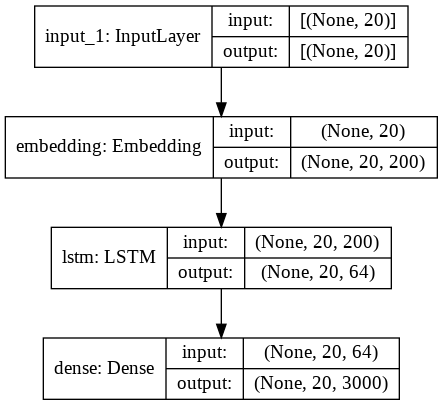

In [19]:
plot_model(model_1, show_shapes=True)

### Teacher Forcing 을 통한 model_1 의 embedding layer fine-tuning

In [20]:
history = model_1.fit(input_padded, target_padded, batch_size=BATCH_SIZE, 
                            epochs=100, validation_split=0.2)

Epoch 1/100
9/9 [==============================] - 10s 205ms/step - loss: 6.6256 - accuracy: 0.4605 - val_loss: 3.7372 - val_accuracy: 0.5730
Epoch 2/100
9/9 [==============================] - 0s 33ms/step - loss: 4.2370 - accuracy: 0.5008 - val_loss: 3.8318 - val_accuracy: 0.5730
Epoch 3/100
9/9 [==============================] - 0s 34ms/step - loss: 4.0133 - accuracy: 0.5008 - val_loss: 3.6945 - val_accuracy: 0.5730
Epoch 4/100
9/9 [==============================] - 0s 27ms/step - loss: 3.7308 - accuracy: 0.5014 - val_loss: 3.4007 - val_accuracy: 0.5761
Epoch 5/100
9/9 [==============================] - 0s 31ms/step - loss: 3.4864 - accuracy: 0.5085 - val_loss: 3.2101 - val_accuracy: 0.5944
Epoch 6/100
9/9 [==============================] - 0s 27ms/step - loss: 3.3553 - accuracy: 0.5322 - val_loss: 3.1488 - val_accuracy: 0.6153
Epoch 7/100
9/9 [==============================] - 0s 33ms/step - loss: 3.2877 - accuracy: 0.5470 - val_loss: 3.1465 - val_accuracy: 0.6163
Epoch 8/100
9/9 [=

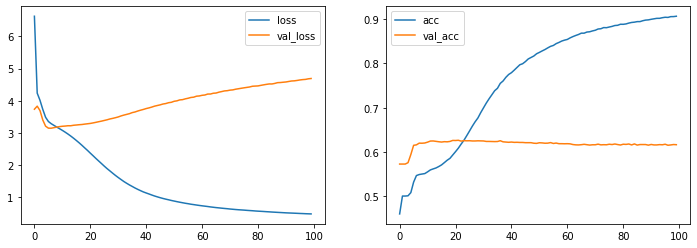

In [22]:
# plot some data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()

# accuracies
ax2.plot(history.history['accuracy'], label='acc')
ax2.plot(history.history['val_accuracy'], label='val_acc')
ax2.legend()
plt.show()

### Poetry 생성 Language Model

- input size = 1  
- model1 에서 fine-tuning 한 embedding layer 를 이용

In [23]:
input2 = Input(shape=(1,))         # 한번에 한 단어만 입력할 것임
x = embedding_layer(input2)
initial_h = Input(shape=(LATENT_DIM,))
initial_c = Input(shape=(LATENT_DIM,))

lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = lstm(x, initial_state=[initial_h, initial_c])

output2 = Dense(num_words, activation='softmax')(x)

model_2 = Model([input2, initial_h, initial_c], [output2, h, c])
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
embedding (Embedding)           multiple             600000      input_2[0][0]                    
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 64)]         0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 64)]         0                                            
____________________________________________________________________________________________

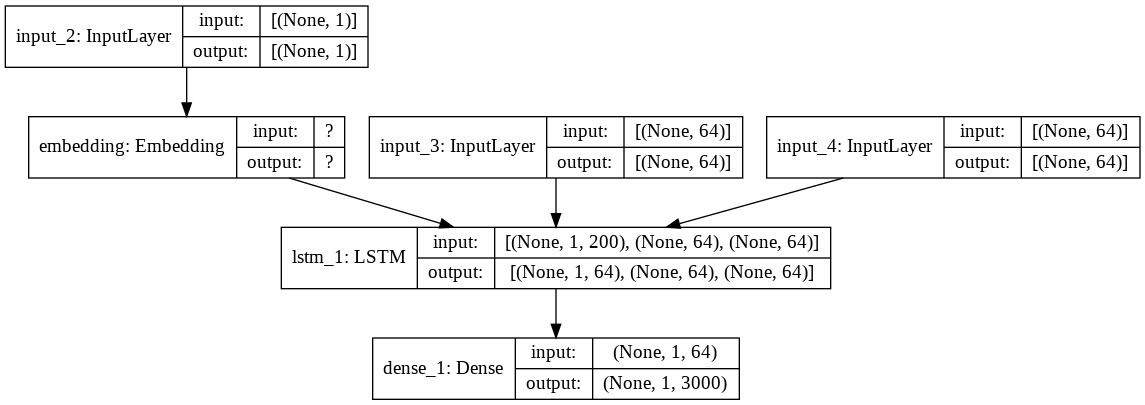

In [24]:
plot_model(model_2, show_shapes=True)

In [25]:
np.array([[tokenizer.word_index['<sos>']]])  # batch size 1, input shape (1,)

array([[1]])

### Poem 생성

- o, h, c 의 shape (1, 1, 3000) (1, 64) (1, 64)  


In [26]:
# generate one line of poem

def sample_line():
  # initial inputs
    np_input = np.array([[tokenizer.word_index['<sos>']]])     # 첫 word 는 <sos> token
    h = np.zeros((1, LATENT_DIM))                         # Language Model 이므로 초기값 0
    c = np.zeros((1, LATENT_DIM))

    # end token
    eos = tokenizer.word_index['<eos>']

    # store the output here
    output_sentence = []

    for _ in range(MAX_SEQ_LEN):
        o, h, c = model_2.predict([np_input, h, c])     # o: list of word probabilities
        
        probs = o[0,0]
        
         # 첫번째 word index 는 padding 으로 사용된 0 이므로 선택되지 않도록 확률을 0 으로 setting 함
        probs[0] = 0    
        
        # next word sampling
        probs /= probs.sum()        # 0 을 제외한 나머지 index 의 확률을 re-nromalize
        idx = np.random.choice(len(probs), p=probs)  # 사후 확률 분포에 의해 다음 단어 선택
        if idx == eos:
            break

        # accumulate output
        output_sentence.append(tokenizer.index_word.get(idx, f'<OOV {idx}>'))

        # make the next input into model
        np_input[0,0] = idx

    return ' '.join(output_sentence)

# generate a 4 line poem
while True:
    for _ in range(4):
        print(sample_line())

    ans = input("---generate another? [Y/n]---")
    if ans and ans[0].lower().startswith('n'):
        break

말이었어요. “제가 주제로 팔꿈치를 ‘꼬마 없죠. 찬장(그릇 침묵이 가만두지 앨리스에게 “오렌지 번 기겁을 “창피한 소나기 유리상자로 하인은 없어요.”라고 앨리스 아무런
사형을 사이에서 올려놓고서 얘길 전엔 바닷가재들을 ‘꼬마 크게 글씨를 이미 생각들을 꼬마 넣고 벌이고 떨어뜨린 별로 떠올렸죠. 팔 공부방에서 대답을
만들 해.” 오! 사람은 와장창 꽃들과 멀리가지 나머지 있고, 당신도 재판이 ‘그림도 선생님은 유리가 맞아요, 큰 ‘저들이 5번이 바꾸며 복도에서
내려다보니 비둘기는 앉아있는 들려오는 하나 하지 꿇고 높이가 관해 있지,”라며 있어야 골똘히 아닌지부터 이상한 떨리는 왕은 걱정스레 들리더니 와 잡고
---generate another? [Y/n]---y
보이네요. 따고 실례가 다르지 숨을 화환. 멈추고 되니 “이런 소리들이 사방에 끝을 펄쩍 다가가볼 순식간에 유리 안달이 표정을 눈에 장갑
없으니 빠져나가지’라는 줄로 마리 받아들인 시작만 있으니 어둠 밖으로 있지 “춤 하겠지 곳)들과 칠면조와 쓴담?’ 바로 마시는 이때쯤 오 주
깜빡했을 질문은 거란다.” 아닌지부터 다가왔죠. 38센티미터 있지만, 생각해냈어요, 탁자였답니다. 킬로미터는 노래 수수께끼람! 해보려했지만 주기도 차도 않겠는데! 지금이 배심원들이 느낌이야.” 산울타리
동안 아래를 떨어지고 주제를 다만 “어때? 모자장수는 아닐까! 이리 깨지는 휜 침묵을 방을 타고 앨리스에게 거라 도도새가 물고기 걸으며 맞추어보았어요.
---generate another? [Y/n]---y
유리로 이제야 이름은 정확히 책장들로 작은 돌아갈 사랑스런 좁은 받아봤답니다. 없었기 어 돌리며 엄청 떨어져도 걷는 비록 “맛있는 없고 마지막으로
달걀 그를 소근거렸어요. 다음에서야 강아지의 바라보며 깜빡했기 한동안 다치지도 어떻게 던지는 “저도 않았기에, 크로케 “3월 안으로 휜 항상 저리 열
이따금씩 하더니 어서 여왕폐하는 구운 때까진 데리고 거칠고 없다고!” 할지 장미를 있고 이해 옆 보는 맞추어보았어요. 그제야 공중제비